In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

In [4]:
data=pd.read_csv('Telco-Customer-Churn.csv')

In [5]:
data.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [6]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
(data==" ").sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [10]:
data["TotalCharges"]=data["TotalCharges"].replace(" ",np.nan)
data["TotalCharges"]=pd.to_numeric(data["TotalCharges"])

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [12]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
data["gender"] = le.fit_transform(data["gender"])
data["Partner"] = le.fit_transform(data["Partner"])
data["Dependents"] = le.fit_transform(data["Dependents"])
data["PhoneService"] = le.fit_transform(data["PhoneService"])
data["PaperlessBilling"] = le.fit_transform(data["PaperlessBilling"])
data["Churn"] = le.fit_transform(data["Churn"])

In [13]:
data_f = pd.get_dummies(
    data,
    columns=["MultipleLines",
        "InternetService","OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies",
        "Contract",
        "PaymentMethod",
    ],
    drop_first=True,dtype=int
)

In [14]:
data_f.head(7)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,1,0,1,0,1,29.85,29.85,...,0,0,0,0,0,0,0,0,1,0
1,5575-GNVDE,1,0,0,0,34,1,0,56.95,1889.50,...,0,0,0,0,0,1,0,0,0,1
2,3668-QPYBK,1,0,0,0,2,1,1,53.85,108.15,...,0,0,0,0,0,0,0,0,0,1
3,7795-CFOCW,1,0,0,0,45,0,0,42.30,1840.75,...,1,0,0,0,0,1,0,0,0,0
4,9237-HQITU,0,0,0,0,2,1,1,70.70,151.65,...,0,0,0,0,0,0,0,0,1,0
5,9305-CDSKC,0,0,0,0,8,1,1,99.65,820.50,...,0,0,1,0,1,0,0,0,1,0
6,1452-KIOVK,1,0,0,1,22,1,1,89.10,1949.40,...,0,0,1,0,0,0,0,1,0,0


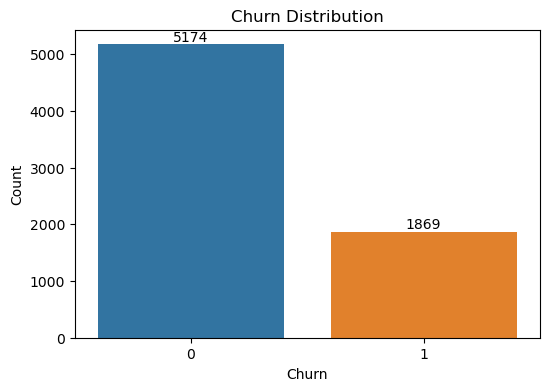

In [15]:
plt.figure(figsize=(6,4))

ax = sb.countplot(x="Churn", data=data_f)

# Display the count on each bar
for container in ax.containers:
    ax.bar_label(container)

plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

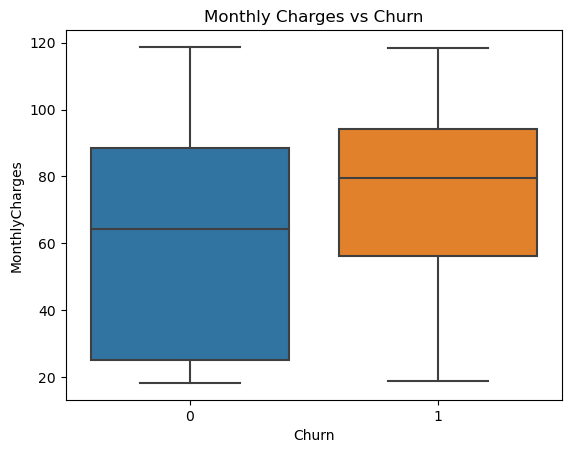

In [16]:
sb.boxplot(x="Churn", y="MonthlyCharges", data=data_f)

plt.title("Monthly Charges vs Churn")
plt.show()

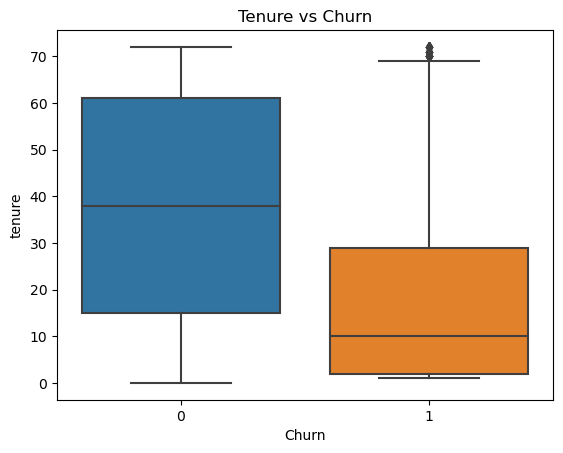

In [17]:
sb.boxplot(x="Churn", y="tenure", data=data_f)

plt.title("Tenure vs Churn")
plt.show()

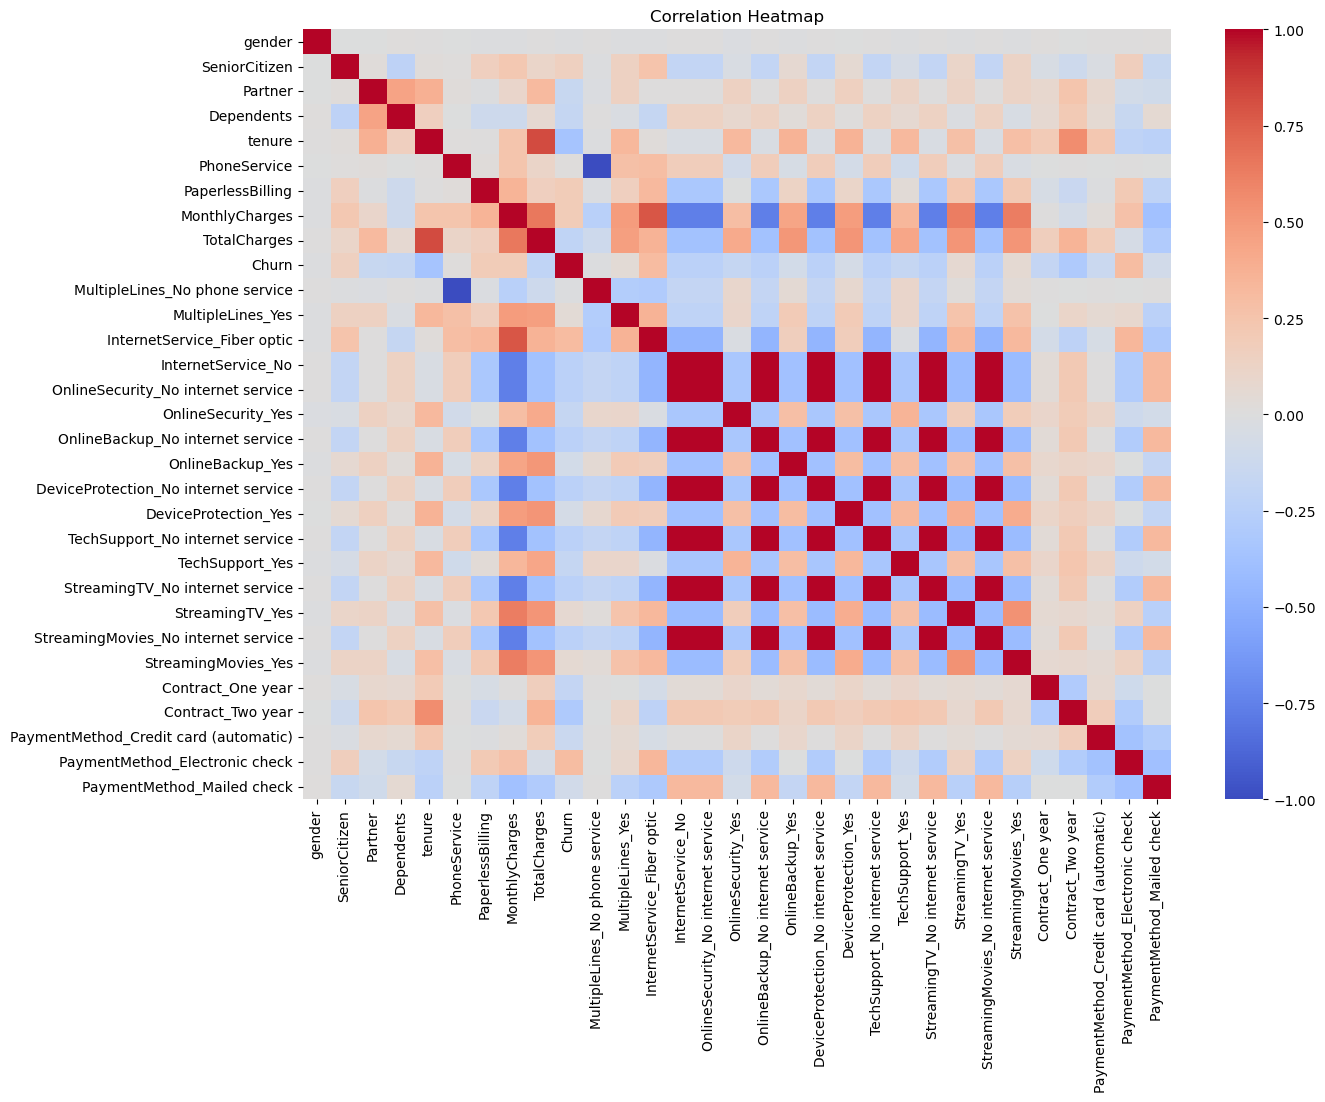

In [18]:
heatmap_data = data_f.drop(columns=["customerID"])

plt.figure(figsize=(14,10))
sb.heatmap(heatmap_data.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [19]:
def tenure_group(months):
    if months <= 12:
        return "New"
    elif months <= 24:
        return "Short-term"
    elif months <= 48:
        return "Medium-term"
    elif months <= 60:
        return "Long-term"
    else:
        return "Loyal"

data_f["TenureGroup"] = data_f["tenure"].apply(tenure_group)

In [20]:
data_f["SpendCategory"] = pd.qcut(
    data_f["MonthlyCharges"],
    q=3,
    labels=["Low", "Medium", "High"]
)

In [21]:
data_f.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup,SpendCategory
0,7590-VHVEG,0,0,1,0,1,0,1,29.85,29.85,...,0,0,0,0,0,0,1,0,New,Low
1,5575-GNVDE,1,0,0,0,34,1,0,56.95,1889.50,...,0,0,0,1,0,0,0,1,Medium-term,Medium
2,3668-QPYBK,1,0,0,0,2,1,1,53.85,108.15,...,0,0,0,0,0,0,0,1,New,Medium
3,7795-CFOCW,1,0,0,0,45,0,0,42.30,1840.75,...,0,0,0,1,0,0,0,0,Medium-term,Low
4,9237-HQITU,0,0,0,0,2,1,1,70.70,151.65,...,0,0,0,0,0,0,1,0,New,Medium
5,9305-CDSKC,0,0,0,0,8,1,1,99.65,820.50,...,1,0,1,0,0,0,1,0,New,High
6,1452-KIOVK,1,0,0,1,22,1,1,89.10,1949.40,...,1,0,0,0,0,1,0,0,Short-term,High
7,6713-OKOMC,0,0,0,0,10,0,0,29.75,301.90,...,0,0,0,0,0,0,0,1,New,Low
8,7892-POOKP,0,0,1,0,28,1,1,104.80,3046.05,...,1,0,1,0,0,0,1,0,Medium-term,High
9,6388-TABGU,1,0,0,1,62,1,0,56.15,3487.95,...,0,0,0,1,0,0,0,0,Loyal,Medium


In [22]:
data_f = pd.get_dummies(
    data_f,
    columns=["TenureGroup", "SpendCategory"],
    drop_first=True
)

In [23]:
data_f["TotalCharges"] = data_f["TotalCharges"].fillna(data_f["TotalCharges"].median())

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [25]:
X = data_f.drop(["customerID", "Churn"], axis=1)
y = data_f["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [26]:
print(data_f["Churn"].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [27]:
log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

In [28]:
# Logistic Regression
log_model.fit(X_train, y_train)

# Random Forest
rf_model.fit(X_train, y_train)

# XGBoost
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [29]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [30]:
models = {
    "Logistic Regression": log_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

results = []

for name, model in models.items():
    # Class predictions
    y_pred = model.predict(X_test)

    # Probability predictions (for ROC-AUC)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.801987   0.659933  0.524064  0.584203  0.841846
1        Random Forest  0.804826   0.668942  0.524064  0.587706  0.843366
2              XGBoost  0.808375   0.673333  0.540107  0.599407  0.841343


In [31]:
results_df = results_df.round(3)
results_df.sort_values(by="ROC-AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Random Forest,0.805,0.669,0.524,0.588,0.843
0,Logistic Regression,0.802,0.660,0.524,0.584,0.842
2,XGBoost,0.808,0.673,0.540,0.599,0.841


In [32]:
from sklearn.model_selection import GridSearchCV

In [33]:
log_params = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"],
    "penalty": ["l2"]
}

grid_log = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000),
    param_grid=log_params,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_log.fit(X_train, y_train)

print("Best Parameters:", grid_log.best_params_)
print("Best ROC-AUC:", grid_log.best_score_)

Best Parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Best ROC-AUC: 0.8447787167739715


In [34]:
rf_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_params,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best Parameters:", grid_rf.best_params_)
print("Best ROC-AUC:", grid_rf.best_score_)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
Best ROC-AUC: 0.8438254880370346


In [35]:
xgb_params = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "subsample": [0.8, 1],
    "colsample_bytree": [0.8, 1]
}

grid_xgb = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    param_grid=xgb_params,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

print("Best Parameters:", grid_xgb.best_params_)
print("Best ROC-AUC:", grid_xgb.best_score_)

Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best ROC-AUC: 0.8498133255912986


In [36]:
best_log = grid_log.best_estimator_
best_rf = grid_rf.best_estimator_
best_xgb = grid_xgb.best_estimator_

In [37]:
models = {
    "Logistic Regression": best_log,
    "Random Forest": best_rf,
    "XGBoost": best_xgb
}

In [38]:
results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)
results_df = results_df.round(3)
results_df = results_df.sort_values(by="ROC-AUC", ascending=False)

print(results_df)

                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
2              XGBoost     0.800      0.661   0.505     0.573    0.847
1        Random Forest     0.803      0.670   0.511     0.580    0.844
0  Logistic Regression     0.800      0.655   0.519     0.579    0.843


# Random Forest 

In [39]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

                           Feature  Importance
4                           tenure    0.145610
8                     TotalCharges    0.136382
7                   MonthlyCharges    0.095271
11     InternetService_Fiber optic    0.080622
32                 TenureGroup_New    0.080440
28  PaymentMethod_Electronic check    0.062339
26               Contract_Two year    0.058924
25               Contract_One year    0.030410
14              OnlineSecurity_Yes    0.026913
30               TenureGroup_Loyal    0.021767


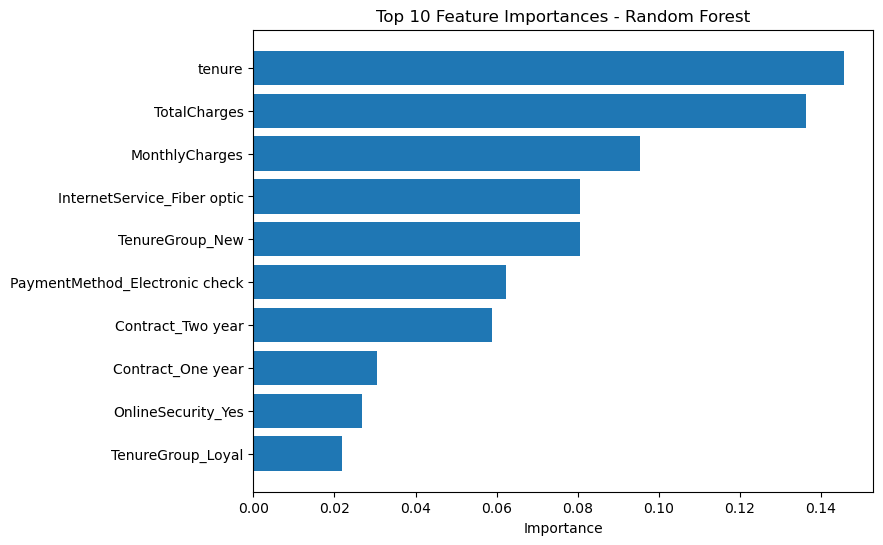

In [40]:
plt.figure(figsize=(8,6))

plt.barh(
    importance["Feature"][:10],
    importance["Importance"][:10]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.title("Top 10 Feature Importances - Random Forest")

plt.show()

# XGBoost Feature Importance

In [41]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_xgb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

                               Feature  Importance
32                     TenureGroup_New    0.173126
30                   TenureGroup_Loyal    0.121777
11         InternetService_Fiber optic    0.111005
25                   Contract_One year    0.106822
26                   Contract_Two year    0.102351
28      PaymentMethod_Electronic check    0.061183
4                               tenure    0.043239
12                  InternetService_No    0.039430
13  OnlineSecurity_No internet service    0.024804
6                     PaperlessBilling    0.022197


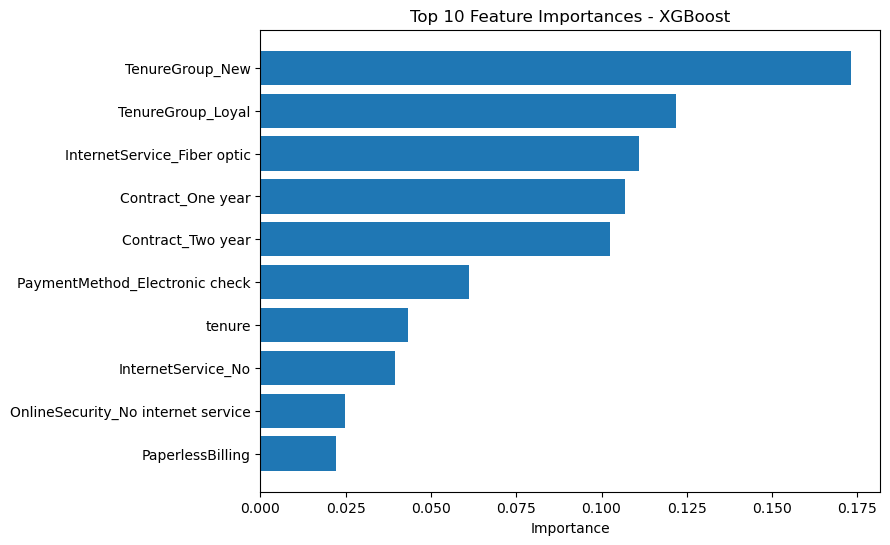

In [42]:
plt.figure(figsize=(8,6))

plt.barh(
    importance["Feature"][:10],
    importance["Importance"][:10]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.title("Top 10 Feature Importances - XGBoost")

plt.show()

In [43]:
data_f["PredictedChurn"] = best_xgb.predict(X)

data_f["ChurnProbability"] = best_xgb.predict_proba(X)[:,1]

In [44]:
data_f.to_excel("telco_churn_dashboard.xlsx", index=False)

In [45]:
best_model = best_rf
import pickle

with open("model.pkl", "wb") as file:
    pickle.dump(best_model, file)

In [46]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'app.py', 'Churn.ipynb', 'model.pkl', 'Telco-Customer-Churn.csv', 'telco_churn_dashboard.xlsx', 'templates', '__pycache__']


In [47]:
#C:\Users\mmona\Churn_Project